In [2]:
import numpy as np
import pandas as pd
data = pd.read_csv(r'C:\Users\jack1\car price\data\quikr_car.csv')

In [3]:
data.head

<bound method NDFrame.head of                                        name    company  year          Price  \
0      Hyundai Santro Xing XO eRLX Euro III    Hyundai  2007         80,000   
1                   Mahindra Jeep CL550 MDI   Mahindra  2006       4,25,000   
2                Maruti Suzuki Alto 800 Vxi     Maruti  2018  Ask For Price   
3    Hyundai Grand i10 Magna 1.2 Kappa VTVT    Hyundai  2014       3,25,000   
4          Ford EcoSport Titanium 1.5L TDCi       Ford  2014       5,75,000   
..                                      ...        ...   ...            ...   
887                                      Ta       Tara  zest       3,10,000   
888                     Tata Zest XM Diesel       Tata  2018       2,60,000   
889                      Mahindra Quanto C8   Mahindra  2013       3,90,000   
890                Honda Amaze 1.2 E i VTEC      Honda  2014       1,80,000   
891               Chevrolet Sail 1.2 LT ABS  Chevrolet  2014       1,60,000   

     kms_driven fuel_

# DATA CLEANING

In [4]:
data['year']

0      2007
1      2006
2      2018
3      2014
4      2014
       ... 
887    zest
888    2018
889    2013
890    2014
891    2014
Name: year, Length: 892, dtype: str

In [5]:
data['year'].value_counts()

year
2015    117
2014     94
2013     94
2016     76
2012     75
       ... 
cab       1
t xe      1
EV2       1
r...      1
zest      1
Name: count, Length: 61, dtype: int64

In [6]:
data['year'].isnull().sum() # no missing value in this column.

np.int64(0)

In [7]:
data['year'] = pd.to_numeric(data['year'], errors='coerce')


In [8]:
data['year'].value_counts()

year
2015.0    117
2014.0     94
2013.0     94
2016.0     76
2012.0     75
2011.0     60
2017.0     56
2009.0     56
2010.0     44
2018.0     34
2006.0     22
2019.0     22
2007.0     19
2008.0     16
2005.0     13
2003.0     13
2004.0     12
2000.0      7
2002.0      5
2001.0      5
1995.0      2
Name: count, dtype: int64

In [9]:
data['year'].isnull().sum()

np.int64(50)

In [10]:
data['year'] = data['year'].fillna(data.groupby('company')['year'].transform('median'))
data['year'] = data['year'].fillna(data['year'].median())
data['year'] = data['year'].astype(int)

In [11]:
data['year'].value_counts()

year
2013    135
2015    117
2014    102
2016     76
2012     75
2011     60
2017     57
2009     56
2010     44
2018     34
2006     22
2019     22
2007     19
2008     16
2005     13
2003     13
2004     12
2000      7
2002      5
2001      5
1995      2
Name: count, dtype: int64

In [12]:
data['year'].shape

(892,)

# 2. price column


In [13]:
data['Price']

0             80,000
1           4,25,000
2      Ask For Price
3           3,25,000
4           5,75,000
           ...      
887         3,10,000
888         2,60,000
889         3,90,000
890         1,80,000
891         1,60,000
Name: Price, Length: 892, dtype: str

In [14]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        892 non-null    str  
 1   company     892 non-null    str  
 2   year        892 non-null    int64
 3   Price       892 non-null    str  
 4   kms_driven  840 non-null    str  
 5   fuel_type   837 non-null    str  
dtypes: int64(1), str(5)
memory usage: 41.9 KB


In [15]:
data['Price'].unique()

<StringArray>
[       '80,000',      '4,25,000', 'Ask For Price',      '3,25,000',
      '5,75,000',      '1,75,000',      '1,90,000',      '8,30,000',
      '2,50,000',      '1,82,000',
 ...
        '42,000',      '1,89,000',      '1,62,000',        '35,999',
     '29,00,000',        '39,999',        '50,500',      '5,10,000',
      '8,60,000',      '5,00,001']
Length: 274, dtype: str

In [16]:
data['Price'].value_counts()

Price
Ask For Price    35
2,50,000         17
3,50,000         14
1,80,000         13
4,00,000         12
                 ..
39,999            1
50,500            1
5,10,000          1
8,60,000          1
5,00,001          1
Name: count, Length: 274, dtype: int64

In [17]:
 data=data[data['Price'] != 'Ask For Price']

In [18]:
data['Price'].shape

(857,)

In [19]:
# removing the commas.
data['Price'] = data['Price'].str.replace(',','')


In [20]:
data['Price'].value_counts()

Price
250000    17
350000    14
180000    13
400000    12
130000    12
          ..
39999      1
50500      1
510000     1
860000     1
500001     1
Name: count, Length: 273, dtype: int64

In [21]:
data['Price'] = data['Price'].astype(int)

In [22]:
data['Price'].value_counts()

Price
250000    17
350000    14
180000    13
400000    12
130000    12
          ..
39999      1
50500      1
510000     1
860000     1
500001     1
Name: count, Length: 273, dtype: int64

In [23]:
# 3. kms_driven.
data['kms_driven']

0      45,000 kms
1          40 kms
3      28,000 kms
4      36,000 kms
6      41,000 kms
          ...    
887           NaN
888    27,000 kms
889    40,000 kms
890        Petrol
891        Petrol
Name: kms_driven, Length: 857, dtype: str

In [24]:
data['kms_driven'].unique()

<StringArray>
[  '45,000 kms',       '40 kms',   '28,000 kms',   '36,000 kms',
   '41,000 kms',   '25,000 kms',   '24,530 kms',   '60,000 kms',
   '30,000 kms',   '32,000 kms',
 ...
   '33,400 kms',   '60,123 kms', '1,37,495 kms',   '91,200 kms',
 '1,46,000 kms', '1,00,800 kms',    '2,100 kms',    '2,500 kms',
 '1,32,000 kms',       'Petrol']
Length: 251, dtype: str

In [59]:
data['kms_driven'].value_counts()

kms_driven
45,000 kms      30
35,000 kms      29
55,000 kms      25
50,000 kms      23
20,000 kms      21
                ..
1,00,200 kms     1
65 kms           1
30,874 kms       1
1,03,553 kms     1
72,160 kms       1
Name: count, Length: 250, dtype: int64

In [25]:
data['kms_driven']

0      45,000 kms
1          40 kms
3      28,000 kms
4      36,000 kms
6      41,000 kms
          ...    
887           NaN
888    27,000 kms
889    40,000 kms
890        Petrol
891        Petrol
Name: kms_driven, Length: 857, dtype: str

In [26]:
data['kms_driven'].isnull().sum()

np.int64(38)

In [27]:
data['kms_driven'] = data['kms_driven'].str.replace('kms','')
data['kms_driven'] = data['kms_driven'].str.replace(',','')

In [28]:
data['kms_driven']

0      45000 
1         40 
3      28000 
4      36000 
6      41000 
        ...  
887       NaN
888    27000 
889    40000 
890    Petrol
891    Petrol
Name: kms_driven, Length: 857, dtype: str

In [29]:
data['kms_driven'] = pd.to_numeric(data['kms_driven'], errors='coerce')


In [30]:
data['kms_driven'] = data['kms_driven'].fillna(data['kms_driven'].median())
data['kms_driven'] = data['kms_driven'].astype(int)

In [31]:
data['kms_driven'].value_counts()

kms_driven
41000     56
45000     30
35000     29
55000     25
50000     23
          ..
146000     1
100800     1
2100       1
2500       1
132000     1
Name: count, Length: 247, dtype: int64

In [32]:
data['kms_driven'].shape

(857,)

In [33]:
data['kms_driven']

0      45000
1         40
3      28000
4      36000
6      41000
       ...  
887    41000
888    27000
889    40000
890    41000
891    41000
Name: kms_driven, Length: 857, dtype: int64

In [34]:
# 4. fuel_type
data['fuel_type']

0      Petrol
1      Diesel
3      Petrol
4      Diesel
6      Diesel
        ...  
887       NaN
888    Diesel
889    Diesel
890       NaN
891       NaN
Name: fuel_type, Length: 857, dtype: str

In [35]:
data['fuel_type'].unique()

<StringArray>
['Petrol', 'Diesel', nan, 'LPG']
Length: 4, dtype: str

In [36]:
data['fuel_type'].value_counts()

fuel_type
Petrol    428
Diesel    386
LPG         2
Name: count, dtype: int64

In [37]:
data['fuel_type'].isnull().sum()

np.int64(41)

In [38]:
data = data.dropna(subset=['fuel_type'])

In [39]:
data['fuel_type']

0      Petrol
1      Diesel
3      Petrol
4      Diesel
6      Diesel
        ...  
883    Petrol
885    Diesel
886    Petrol
888    Diesel
889    Diesel
Name: fuel_type, Length: 816, dtype: str

In [40]:
data['fuel_type'].shape

(816,)

In [79]:
data

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40,Diesel
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000,Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000,Diesel
6,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
883,Maruti Suzuki Ritz VXI ABS,Maruti,2011,270000,50000,Petrol
885,Tata Indica V2 DLE BS III,Tata,2009,110000,30000,Diesel
886,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
888,Tata Zest XM Diesel,Tata,2018,260000,27000,Diesel


In [41]:
# 4. NAME COLUMN
data['name']

0        Hyundai Santro Xing XO eRLX Euro III
1                     Mahindra Jeep CL550 MDI
3      Hyundai Grand i10 Magna 1.2 Kappa VTVT
4            Ford EcoSport Titanium 1.5L TDCi
6                                   Ford Figo
                        ...                  
883                Maruti Suzuki Ritz VXI ABS
885                 Tata Indica V2 DLE BS III
886                      Toyota Corolla Altis
888                       Tata Zest XM Diesel
889                        Mahindra Quanto C8
Name: name, Length: 816, dtype: str

In [42]:
data['name'].unique()

<StringArray>
[  'Hyundai Santro Xing XO eRLX Euro III',
                'Mahindra Jeep CL550 MDI',
 'Hyundai Grand i10 Magna 1.2 Kappa VTVT',
       'Ford EcoSport Titanium 1.5L TDCi',
                              'Ford Figo',
                            'Hyundai Eon',
       'Ford EcoSport Ambiente 1.5L TDCi',
         'Maruti Suzuki Alto K10 VXi AMT',
            'Skoda Fabia Classic 1.2 MPI',
             'Maruti Suzuki Stingray VXi',
 ...
                     'Mahindra Quanto C4',
              'Maruti Suzuki Swift Dzire',
             'Hyundai i20 Select Variant',
                   'Honda City VX Petrol',
                           'Hyundai Getz',
         'Mercedes Benz C Class 200 K MT',
                            'Skoda Fabia',
             'Maruti Suzuki Ritz VXI ABS',
              'Tata Indica V2 DLE BS III',
                    'Tata Zest XM Diesel']
Length: 463, dtype: str

In [43]:
data['name'].value_counts()

name
Honda City                                 13
Honda Amaze                                11
Maruti Suzuki Dzire                        10
Mahindra Scorpio S10                        9
Maruti Suzuki Swift Dzire VXi 1.2 BS IV     7
                                           ..
Mercedes Benz C Class 200 K MT              1
Skoda Fabia                                 1
Maruti Suzuki Ritz VXI ABS                  1
Tata Indica V2 DLE BS III                   1
Tata Zest XM Diesel                         1
Name: count, Length: 463, dtype: int64

In [44]:
data['name'] = data['name'].str.split().str[:3].str.join('')

In [45]:
data.head()

,name,company,year,Price,kms_driven,fuel_type
0,HyundaiSantroXing,Hyundai,2007,80000,45000,Petrol
1,MahindraJeepCL550,Mahindra,2006,425000,40,Diesel
3,HyundaiGrandi10,Hyundai,2014,325000,28000,Petrol
4,FordEcoSportTitanium,Ford,2014,575000,36000,Diesel
6,FordFigo,Ford,2012,175000,41000,Diesel


In [46]:
data.info()

<class 'pandas.DataFrame'>
Index: 816 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    str   
 2   year        816 non-null    int64 
 3   Price       816 non-null    int64 
 4   kms_driven  816 non-null    int64 
 5   fuel_type   816 non-null    str   
dtypes: int64(3), object(1), str(2)
memory usage: 44.6+ KB


In [47]:
data.reset_index(drop=True , inplace=True)

In [49]:
data.to_csv('Cleaned_Car_data.csv' , index=False)
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
sns.set_theme(style="whitegrid")

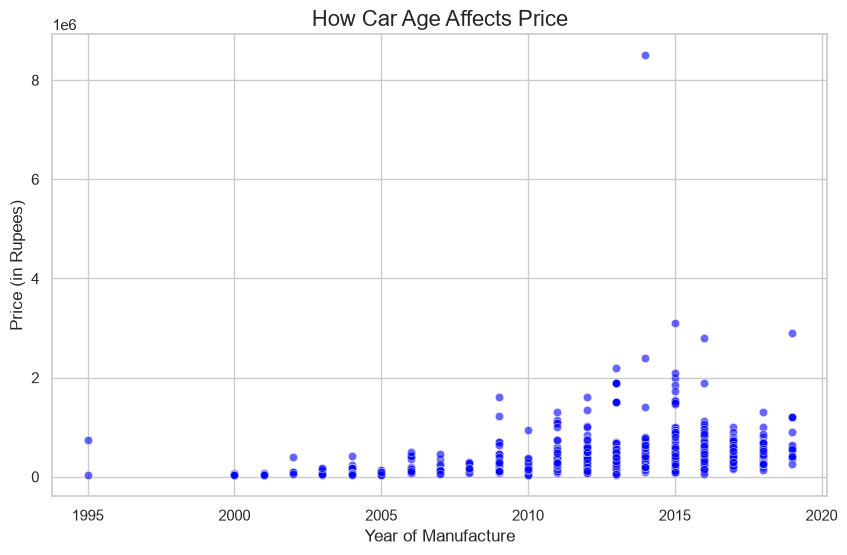

In [51]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='year', y='Price', data=data, color='blue', alpha=0.6)

plt.title('How Car Age Affects Price', fontsize=16)
plt.xlabel('Year of Manufacture', fontsize=12)
plt.ylabel('Price (in Rupees)', fontsize=12)
plt.show()

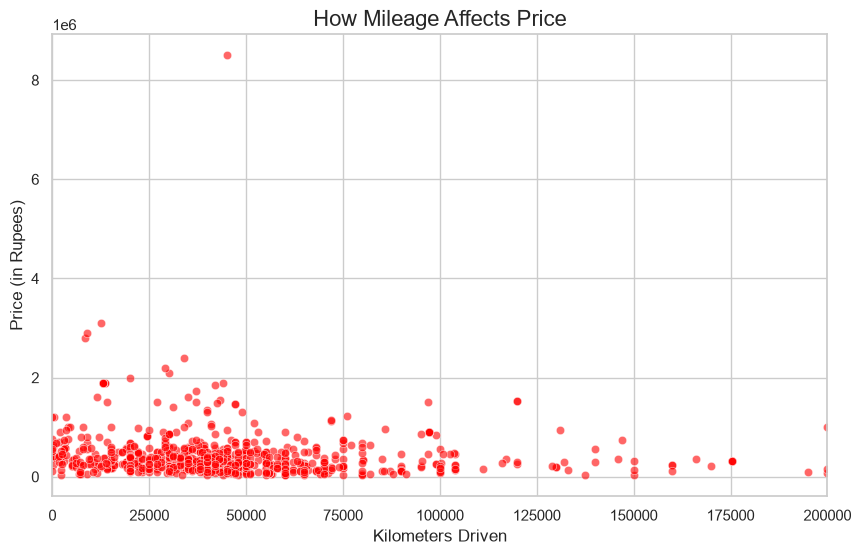

In [52]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='kms_driven', y='Price', data=data, color='red', alpha=0.6)

plt.title('How Mileage Affects Price', fontsize=16)
plt.xlabel('Kilometers Driven', fontsize=12)
plt.ylabel('Price (in Rupees)', fontsize=12)

# Optional: Limit the x-axis to zoom in on the majority of the data
plt.xlim(0, 200000) 
plt.show()

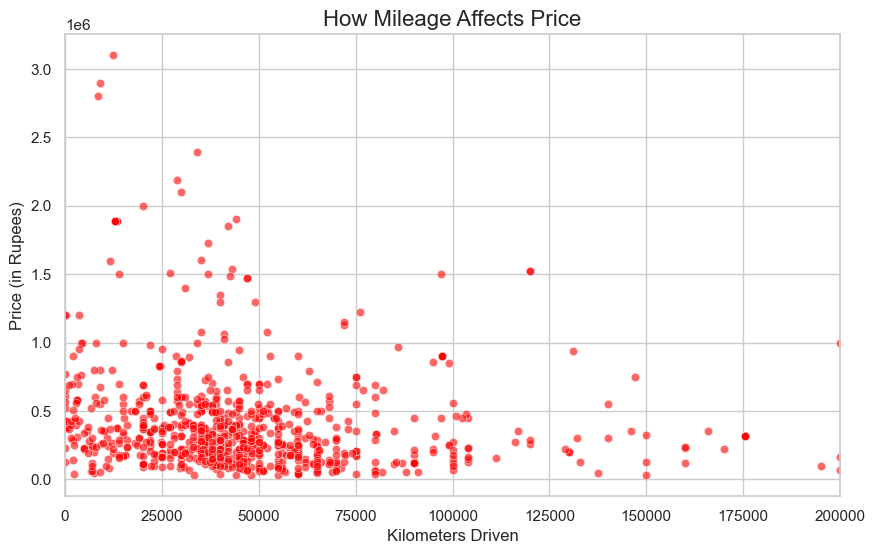

In [116]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='kms_driven', y='Price', data=data, color='red', alpha=0.6)

plt.title('How Mileage Affects Price', fontsize=16)
plt.xlabel('Kilometers Driven', fontsize=12)
plt.ylabel('Price (in Rupees)', fontsize=12)

# Optional: Limit the x-axis to zoom in on the majority of the data
plt.xlim(0, 200000) 
plt.show()

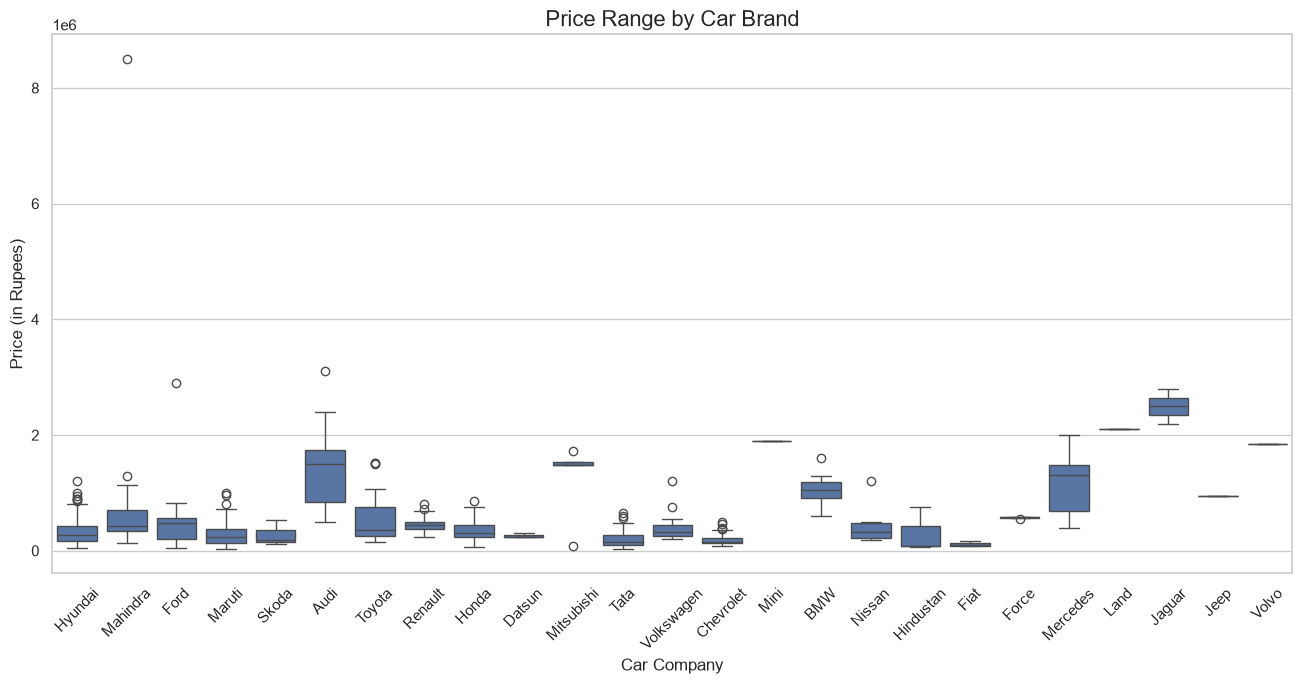

In [53]:
plt.figure(figsize=(16, 7))
sns.boxplot(x='company', y='Price', data=data)

plt.title('Price Range by Car Brand', fontsize=16)
plt.xlabel('Car Company', fontsize=12)
plt.ylabel('Price (in Rupees)', fontsize=12)

# This rotates the company names by 45 degrees so they don't overlap!
plt.xticks(rotation=45) 
plt.show()

In [54]:
y = data['Price']
x= data.drop(columns='Price')

In [55]:
from sklearn.model_selection import train_test_split
x_train, x_test ,y_train , y_test = train_test_split(x , y, test_size=0.2, random_state=42)

In [56]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score

In [57]:
categorical_cols = ['name' , 'company' , 'fuel_type']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat' , OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

In [58]:
lr_pipeline = Pipeline(steps =[
    ('preprocessor', preprocessor),
    ('model' , LinearRegression())
])

In [98]:
lr_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['name', 'company',
                                                   'fuel_type'])])),
                ('model', LinearRegression())])

In [59]:
# previously we donot check the outlier in our data.
data = data[data['Price'] < 6000000]
x = data.drop(columns='Price')
y = data['Price']

In [60]:
scores = []
best_state = 0
highest_r2 = 0

# Test 1000 different random splits
for i in range(1000):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=i)
    
    lr = LinearRegression()
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', lr)
    ])
    
    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_test)
    score = r2_score(y_test, y_pred)
    
    scores.append(score)
    
    if score > highest_r2:
        highest_r2 = score
        best_state = i

print(f"The absolute best random_state is: {best_state}")

print(f"It produces an R^2 Score of: {highest_r2:.4f}")

The absolute best random_state is: 433
It produces an R^2 Score of: 0.8457


In [61]:
import pickle

# 1. Lock in your golden random_state
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=433)

# 2. Build the winning pipeline
lr = LinearRegression()
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lr)
])

# 3. Train the final model one last time
pipe.fit(x_train, y_train)

# 4. EXPORT THE MODEL
# 'wb' stands for 'write binary'. This saves your entire pipeline (preprocessing + model)
pickle.dump(pipe, open('LinearRegressionModel.pkl', 'wb'))

print("Model successfully saved as LinearRegressionModel.pkl!")

Model successfully saved as LinearRegressionModel.pkl!


In [62]:
import pickle
import pandas as pd

# 1. Load the saved model 
# 'rb' stands for 'read binary' (since we saved it using 'wb')
model = pickle.load(open('LinearRegressionModel.pkl', 'rb'))

# 2. Create a "fake car" using a dictionary, then convert it to a DataFrame
# Let's test a 2019 Hyundai Grand i10 driven for 35,000 kms
fake_car = pd.DataFrame({
    'name': ['Hyundai Grand i10'],
    'company': ['Hyundai'],
    'year': [2019],
    'kms_driven': [35000],
    'fuel_type': ['Petrol']
})

# 3. Ask the model to predict the price
prediction = model.predict(fake_car)

# 4. Print the result, formatting it as an integer so it looks like real currency
print(f"The predicted price for this car is: ₹{int(prediction[0])}")

The predicted price for this car is: ₹495224
